# Naive Bayes Survival Model

Predict continuous Time To Event (TTE): days from one known satellite anomaly to the next for the same satellite. This notebook uses the repository's existing preprocessing and shuffled 10-fold cross-validation workflow.

**Method note:** for each time threshold, Gaussian Naive Bayes estimates the probability that the next anomaly has not happened yet. The predicted TTE is approximated by integrating these survival probabilities over time.

In [1]:
from pathlib import Path
import sys
PROJECT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT) not in sys.path:
    sys.path.insert(0, str(PROJECT))
print("Project directory:", PROJECT)


Project directory: c:\Users\sowmy\OneDrive\Sowmya\College\SEM-5\ML\Satellite-Anomaly-Prediction-ML-Project


In [2]:
# Modified Naive Bayes Survival Model
# Predicts continuous time-to-event (TTE), measured in days.
# This follows the reference paper's idea of estimating survival probabilities
# at multiple time thresholds using a Naive Bayes model.

import sys
from pathlib import Path

# Works when this notebook is run from the repository's notebooks/ folder.
sys.path.insert(0, "..")

import importlib
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.impute import SimpleImputer
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Modified Naive Bayes Survival Model
# Predicts continuous time-to-event (TTE), measured in days.
# This follows the reference paper's idea of estimating survival probabilities
# at multiple time thresholds using a Naive Bayes model.

import sys
from pathlib import Path

# Works when this notebook is run from the repository's notebooks/ folder.
sys.path.insert(0, "..")

import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.impute import SimpleImputer
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error


## Dataset and preprocessing

In [3]:
from pathlib import Path
import pandas as pd
from sklearn.model_selection import KFold

C = type("Config", (), {"N_SPLITS": 10, "RANDOM_STATE": 42})()
df = pd.read_csv(PROJECT / "data" / "processed" / "tte.csv", parse_dates=["start"])
FEATURES = ["month_sin", "month_cos", "sun_27", "sun_81", "sun_trend"] + [f"orbit_{c}" for c in ["G", "I", "C", "E", "P", "V"]] + ["prev_log_gap", "log_n_prev"]
print(f"TTE observations: {len(df)}")
print(f"Satellites retained: {df.sat.nunique()}")
print(f"Feature columns: {FEATURES}")
print(f"TTE range: {df.tte.min()} to {df.tte.max()} days")


TTE observations: 2437
Satellites retained: 37
Feature columns: ['month_sin', 'month_cos', 'sun_27', 'sun_81', 'sun_trend', 'orbit_G', 'orbit_I', 'orbit_C', 'orbit_E', 'orbit_P', 'orbit_V', 'prev_log_gap', 'log_n_prev']
TTE range: 1 to 358 days


## Define the survival Naive Bayes estimator

In [4]:
# Works on both NumPy 1.x (np.trapz) and NumPy 2.x (np.trapezoid)
_trapz = getattr(np, "trapezoid", None) or np.trapz


class NaiveBayesSurvivalRegressor(BaseEstimator, RegressorMixin):
    """
    Modified Naive Bayes TTE regressor.

    For each time threshold t, classify whether TTE > t (the event has not
    happened yet). The survival probability is estimated with GaussianNB.
    Integrating S(t) over a grid gives an estimate of expected TTE.

    This is a practical implementation of the paper's survival-NB idea for
    uncensored TTE observations; it is not an exact reproduction of the
    original author's code.
    """
    def __init__(self, n_time_points=60, var_smoothing=1e-9):
        self.n_time_points = n_time_points
        self.var_smoothing = var_smoothing

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        if np.any(~np.isfinite(y)) or np.any(y <= 0):
            raise ValueError("TTE targets must be finite and positive.")

        # Quantile grid provides more resolution where observed TTE values cluster.
        q = np.linspace(0.02, 0.98, self.n_time_points)
        self.time_grid_ = np.unique(np.quantile(y, q))
        self.models_ = []

        for t in self.time_grid_:
            survived = (y > t).astype(int)
            # At extreme thresholds a fold can contain only one class.
            # Store the empirical survival rate for that threshold in this case.
            if np.unique(survived).size < 2:
                self.models_.append(float(survived.mean()))
            else:
                model = GaussianNB(var_smoothing=self.var_smoothing)
                model.fit(X, survived)
                self.models_.append(model)

        self.max_tte_ = float(np.max(y))
        return self

    def predict_survival(self, X):
        X = np.asarray(X, dtype=float)
        probs = []
        for model in self.models_:
            if isinstance(model, float):
                p = np.full(X.shape[0], model)
            else:
                class_one = np.flatnonzero(model.classes_ == 1)
                p = (model.predict_proba(X)[:, class_one[0]]
                     if len(class_one) else np.zeros(X.shape[0]))
            probs.append(p)
        return np.asarray(probs).T

    def predict(self, X):
        survival = self.predict_survival(X)
        # Integrate estimated survival curve: E[T] = integral S(t) dt.
        # Include S(0)=1 and S(t)=0 beyond the largest training TTE.
        times = np.concatenate(([0.0], self.time_grid_, [self.max_tte_]))
        s0 = np.ones((survival.shape[0], 1))
        s_end = np.zeros((survival.shape[0], 1))
        s = np.concatenate((s0, survival, s_end), axis=1)
        # Trapezoidal integration across the time grid.
        pred = _trapz(s, x=times, axis=1)
        return np.maximum(pred, 0.0)

## Train and evaluate with 10-fold cross-validation

Imputation and scaling are fitted separately inside each training fold to avoid preprocessing leakage.

In [5]:
X = df[FEATURES]
y = df["tte"].to_numpy(dtype=float)

model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("regressor", NaiveBayesSurvivalRegressor(n_time_points=60)),
])

oof_pred = np.full(len(df), np.nan)
fold = np.zeros(len(df), dtype=int)
kfold = KFold(n_splits=C.N_SPLITS, shuffle=True, random_state=C.RANDOM_STATE)

for k, (train_idx, test_idx) in enumerate(kfold.split(X)):
    model.fit(X.iloc[train_idx], y[train_idx])
    oof_pred[test_idx] = model.predict(X.iloc[test_idx])
    fold[test_idx] = k

rae = np.mean(np.abs(oof_pred - y) / y)
mae = mean_absolute_error(y, oof_pred)
rmse = mean_squared_error(y, oof_pred) ** 0.5

print(f"TTE observations: {len(df)}")
print(f"Satellites retained: {df.sat.nunique()}")
print(f"CV folds: {C.N_SPLITS}")
print(f"Naive Bayes Survival RAE: {rae:.6f}")
print(f"Naive Bayes Survival MAE: {mae:.6f} days")
print(f"Naive Bayes Survival RMSE: {rmse:.6f} days")

TTE observations: 2437
Satellites retained: 37
CV folds: 10
Naive Bayes Survival RAE: 30.151401
Naive Bayes Survival MAE: 91.732949 days
Naive Bayes Survival RMSE: 107.400761 days


## Regression plots and save predictions

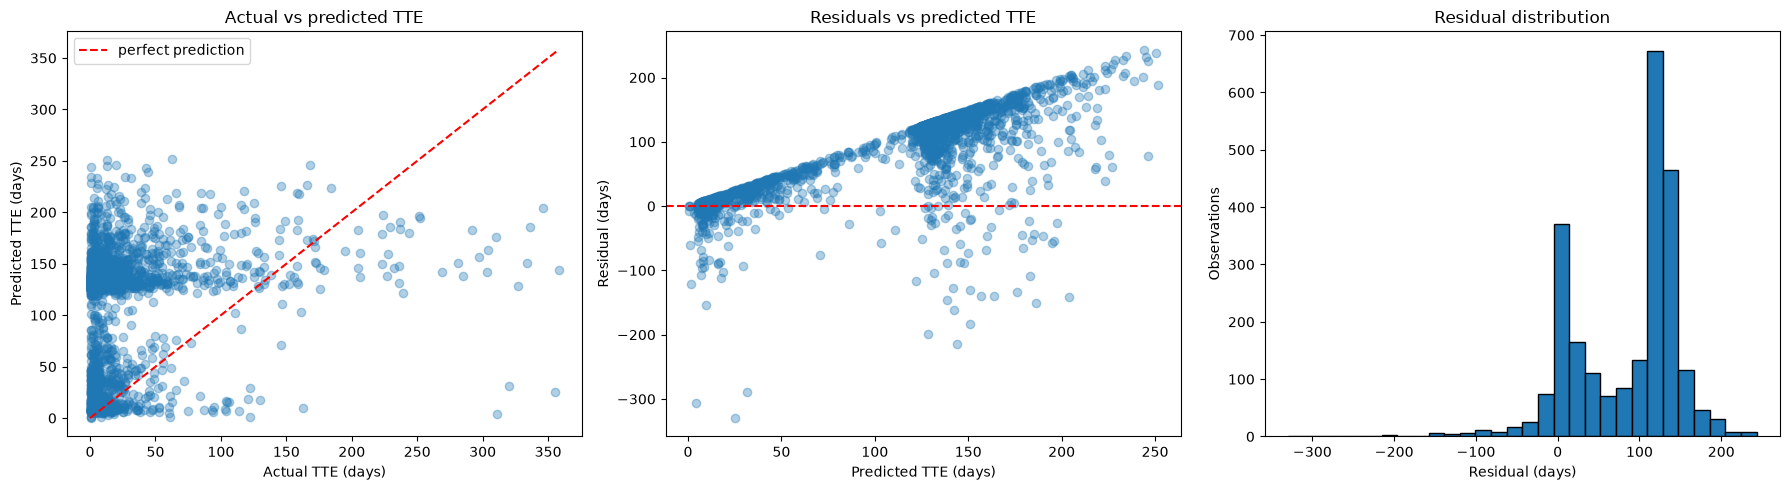

Saved predictions to c:\Users\sowmy\OneDrive\Sowmya\College\SEM-5\ML\Satellite-Anomaly-Prediction-ML-Project\results\predictions_naive_bayes.csv
Saved metrics to c:\Users\sowmy\OneDrive\Sowmya\College\SEM-5\ML\Satellite-Anomaly-Prediction-ML-Project\results\metrics.csv


In [6]:
residuals = oof_pred - y
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y, oof_pred, alpha=0.35)
line_max = max(y.max(), oof_pred.max())
axes[0].plot([0, line_max], [0, line_max], "r--", label="perfect prediction")
axes[0].set_title("Actual vs predicted TTE")
axes[0].set_xlabel("Actual TTE (days)")
axes[0].set_ylabel("Predicted TTE (days)")
axes[0].legend()

axes[1].scatter(oof_pred, residuals, alpha=0.35)
axes[1].axhline(0, color="r", linestyle="--")
axes[1].set_title("Residuals vs predicted TTE")
axes[1].set_xlabel("Predicted TTE (days)")
axes[1].set_ylabel("Residual (days)")

axes[2].hist(residuals, bins=30, edgecolor="black")
axes[2].set_title("Residual distribution")
axes[2].set_xlabel("Residual (days)")
axes[2].set_ylabel("Observations")

plt.tight_layout()
plt.show()

results_dir = PROJECT / "results"
results_dir.mkdir(parents=True, exist_ok=True)
pd.DataFrame({
    "actual_tte": y,
    "predicted_tte": oof_pred,
    "fold": fold,
    "satellite": df["sat"].to_numpy()
}).to_csv(results_dir / "predictions_naive_bayes.csv", index=False)

print(f"Saved predictions to {results_dir / 'predictions_naive_bayes.csv'}")

metrics_row = pd.DataFrame([{
    "model": "Naive Bayes Survival",
    "model_key": "naive_bayes",
    "status": "success",
    "n_observations": len(df),
    "n_satellites": df.sat.nunique(),
    "cv_folds": C.N_SPLITS,
    "rae": rae,
    "rae_percent": rae * 100,
    "mae_days": mae,
    "rmse_days": rmse,
    "configuration": json.dumps({"features": FEATURES, "cv": "shuffled KFold", "random_state": C.RANDOM_STATE})
}])
metrics_path = results_dir / "metrics.csv"
existing = pd.read_csv(metrics_path) if metrics_path.exists() else pd.DataFrame()
if not existing.empty and "model_key" in existing.columns:
    existing = existing[existing.model_key != "naive_bayes"]
pd.concat([existing, metrics_row], ignore_index=True).to_csv(metrics_path, index=False)
print(f"Saved metrics to {metrics_path}")